# Лабораторная работа 6. Гистограмма и частота пересечения нуля

**Цель работы**: знакомство с оценками гистограммы и частоты пересечения нуля (Zero-crossing rate, ZCR) аудио сигналов и исследование свойств оценок этих характеристик.

 <hr>        

<font style="color:#1560BD;" size="5">[Начальные установки](#introduction)</font>

<font style="color:#1560BD;" size="5">[Задание 1. Гистограммы белого шума](#job1)</font>    

<font style="color:#1560BD;" size="5">[Задание 2. Гистограммы тональных сигналов](#job2)</font>    

<font style="color:#1560BD;" size="5">[Задание 3. Гистограммы речевых сигналов](#job3)</font>    

<font style="color:#1560BD;" size="5">[Задание 4. Скорость пересечения нуля (ZCR)](#job4)</font>    

<font style="color:#1560BD;" size="5">[Задание 5. ZCR для обычного и зашумленного речевого сигнала](#job5)</font>    

<font style="color:#1560BD;" size="5">[Задание 6. ZCR для гармонического сигнала различной частоты дискретизации](#job6)</font>    

<font style="color:#1560BD;" size="5">[Задание 7. ZCR для различной частоты дискретизации](#job7)</font>    

### Начальные установки
<a id="introduction"></a>

In [ ]:
# Импорт необходимых библиотек
import matplotlib.pyplot as plt
import librosa
import seaborn as sns
import numpy as np

# Игнорируем предупреждения
from warnings import filterwarnings

filterwarnings("ignore")

In [ ]:
# Проверка версии библиотеки
print(librosa.__version__)

0.11.0


In [ ]:
# Конфигурируем директорию данных
Speech_dir = "/home/artyom/myprojects/ITMO/AEA/mors/speech"  # Речевые треки для текущей лабораторной работы

# Основные частоты дискретизации
sr8000 = 8000
sr11025 = 11025
sr22050 = 22050
sr44100 = 44100

<div class="alert alert-block alert-info">
<b>Задание 1. Гистограммы белого шума</b> 
<a id="job1"></a>

* Возьмите сигнал белого шума **8k_white_noise.wav** и постройте в одном окне его гистограммы с числом бинов $10, 100, 1000$.
* Объясните, в чем заключается и чем объясняется различие оценок гистограмм?
</div>

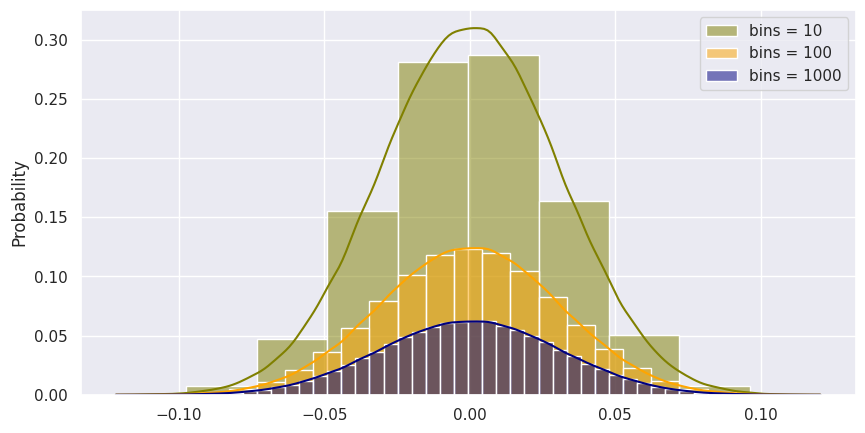

Стандартное отклонение: 0.03047285


In [ ]:
# Загружаем сигнал 8k_white_noise.wav (с частотой 8000)
data_white_noise, sr_white_noise = librosa.load(
    Speech_dir + "//8k_white_noise.WAV", sr=sr8000
)

# Создаем и визуализируем гистограммы
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data_white_noise,
    kde=True,
    stat="probability",
    bins=10,
    color="olive",
    label="bins = 10",
    ax=ax,
)
sns.histplot(
    data_white_noise,
    kde=True,
    stat="probability",
    bins=25,
    color="orange",
    label="bins = 100",
    ax=ax,
)
sns.histplot(
    data_white_noise,
    kde=True,
    stat="probability",
    bins=50,
    color="navy",
    label="bins = 1000",
    ax=ax,
)

plt.legend()
plt.show()

white_noise_std = np.std(data_white_noise)
print("Стандартное отклонение:", white_noise_std)

<div class="alert alert-block alert-success">
<b>Ответ на задание 1:</b>
<a id="answer-job1"></a>

* Объясните, в чем заключается и чем объясняется различие оценок гистограмм?

Больше бинов - больше сглаживание между 

</div>

<div class="alert alert-block alert-info">
<b>Задание 2. Гистограммы тональных сигналов</b>
<a id="job2"></a>

* Возьмите тональные сигналы **8kHz_sin.wav** и **8kHz_sin77.wav**, постройте в одном окне их гистограммы с числом бинов $100$.
* Объясните характер гистограмм.
</div>

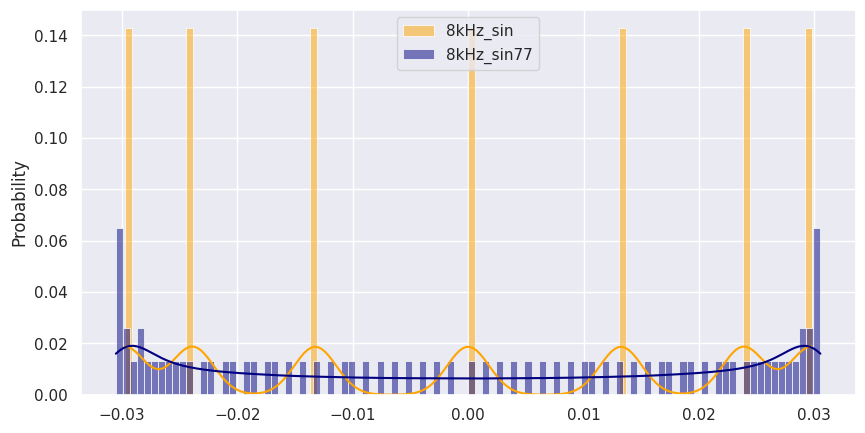

In [ ]:
# Загружаем сигнал 8kHz_sin.wav (с частотой 8000)
data_8_kHz_sin, sr_8_kHz_sin = librosa.load(Speech_dir + "//8kHz_sin.wav", sr=sr8000)

# Загружаем сигнал 8kHz_sin77.wav (с частотой 8000)
data_8_kHz_sin77, sr_8_kHz_sin77 = librosa.load(
    Speech_dir + "//8kHz_sin77.wav", sr=sr8000
)

# Создаем и визуализируем гистограммы
sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data_8_kHz_sin,
    kde=True,
    stat="probability",
    bins=100,
    color="orange",
    label="8kHz_sin",
    ax=ax,
)
sns.histplot(
    data_8_kHz_sin77,
    kde=True,
    stat="probability",
    bins=100,
    color="navy",
    label="8kHz_sin77",
    ax=ax,
)
plt.legend()
plt.show()

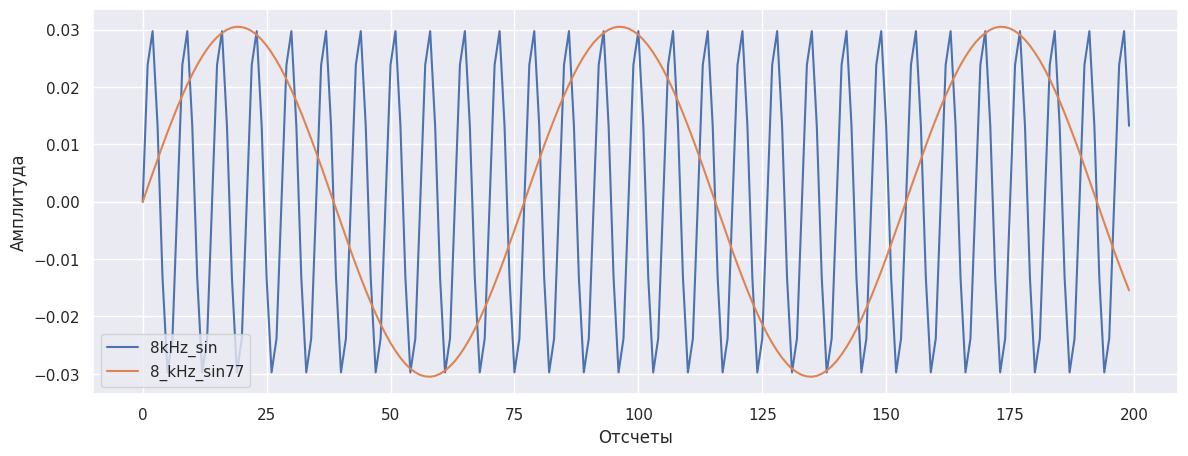

In [ ]:
# Осцилограммы сигналов 8kHz_sin.wav и 8kHz_sin77.wav
n0 = 0
n1 = 200
plt.figure(figsize=(14, 5))
plt.plot(data_8_kHz_sin[n0:n1], label="8kHz_sin")
plt.plot(data_8_kHz_sin77[n0:n1], label="8_kHz_sin77")
plt.grid(True)
plt.xlabel("Отсчеты")
plt.ylabel("Амплитуда")
plt.legend()
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 2:</b>
<a id="answer-job2"></a>

* Объясните характер гистограмм.

У 8_kHz_sin77 гистограмма изображена с пиками по краям.
Это связано с тем, что у этого сигнала достаточно низкая частота, благодаря чему отсчёты распределены более равномерно и не всхлопываются в пики, как у второго сигнала

</div>

<div class="alert alert-block alert-info">
<b>Задание 3. Гистограммы речевых сигналов</b>
<a id="job3"></a>

* Возьмите речевой сигнал **SPCH_ME.wav**, постройте его гистограмму с числом бинов $30$.
* Возьмите речевой сигнал **histogram_8khz.wav**, постройте его гистограмму с числом бинов $30$.
* Объясните, в чем заключается и чем объясняется различие оценок гистограмм?
</div>

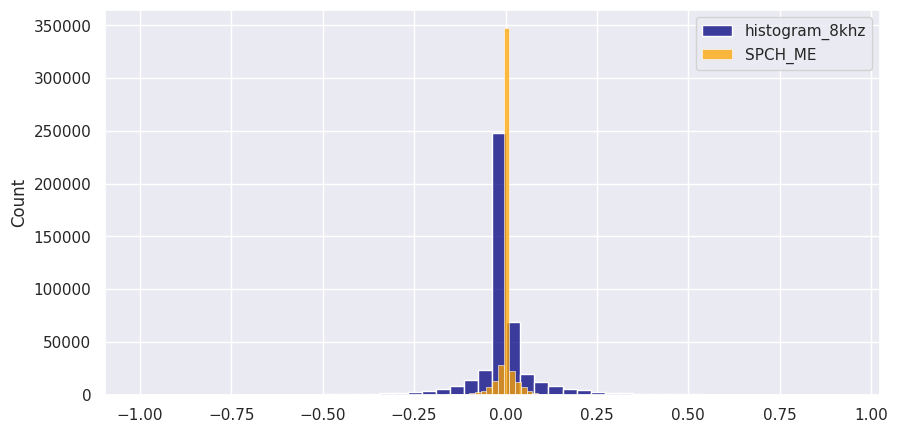

In [ ]:
# Загружаем сигнал SPCH_ME.wav (с частотой 8000)
data_SPCH_ME, sr_SPCH_ME = librosa.load(Speech_dir + "//SPCH_ME.wav", sr=sr8000)

# Загружаем сигнал histogram_8khz.wav (с частотой 8000)
data_histogram_8khz, sr_histogram_8khz = librosa.load(
    Speech_dir + "//histogram_8khz.wav", sr=sr8000
)

# Создаем и визуализируем гистограммы
sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data_histogram_8khz,
    stat="count",
    bins=50,
    color="navy",
    label="histogram_8khz",
    ax=ax,
)
sns.histplot(
    data_SPCH_ME, stat="count", bins=50, color="orange", label="SPCH_ME", ax=ax
)

plt.legend()
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 3:</b>
<a id="answer-job3"></a>

* Объясните, в чем заключается и чем объясняется различие оценок гистограмм?

У `SPCH_ME` за счёт наличия согласных и пауз в речи общая энергия оказывается низкая, из-за чего отсчёты группируются возле 0.

</div>

<div class="alert alert-block alert-info">
<b>Задание 4. Скорость пересечения нуля - Zero Crossing Rate (ZCR)</b>
<a id="zcr"></a>

* Возьмите сигнал **11_100HZ.wav**. Постройте для него графики ZCR с разным размером окна анализа (размером кадра): $20$ мс, $200$ мс. 

* Как оценка ZCR связана с размером кадра?

* Добавьте к сигналу константу $0.122$ (c учетом нормировки сигнала в $(-1,1)$) и постройте для него графики ZCR. 

* Как изменится ZCR? Объясните результаты.
</div>

In [ ]:
# Загрузка (с частотой 11025) сигнала
data_11_100HZ, sr_11_100HZ = librosa.load(Speech_dir + "//11_100HZ.wav", sr=sr11025)

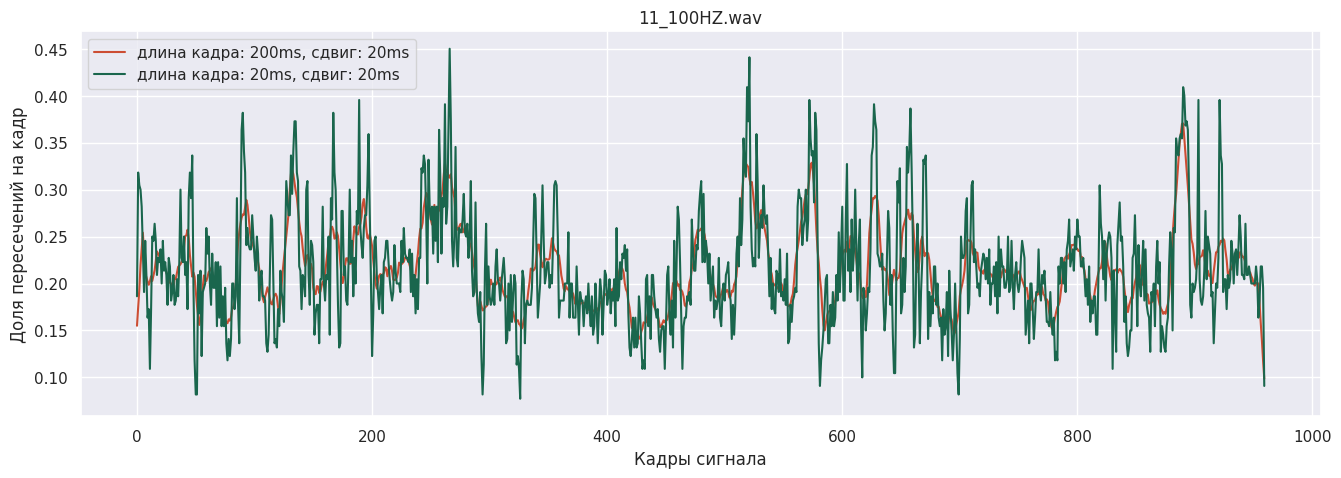

In [ ]:
# Строим графики ZCR с разным размером окна анализа (в мс):
t20 = 220
t200 = 2200
plt.figure(figsize=(16, 5))
z200 = librosa.feature.zero_crossing_rate(
    data_11_100HZ, frame_length=t200, hop_length=t20
)
plt.title("11_100HZ.wav")
plt.plot(z200[0], label="длина кадра: 200ms, сдвиг: 20ms", color=[0.8, 0.3, 0.2])

z20 = librosa.feature.zero_crossing_rate(
    data_11_100HZ, frame_length=t20, hop_length=t20
)
plt.plot(z20[0], label="длина кадра: 20ms, сдвиг: 20ms", color=[0.1, 0.4, 0.3])
plt.ylabel("Доля пересечений на кадр")
plt.xlabel("Кадры сигнала")

plt.grid(True)
plt.legend()
plt.show()

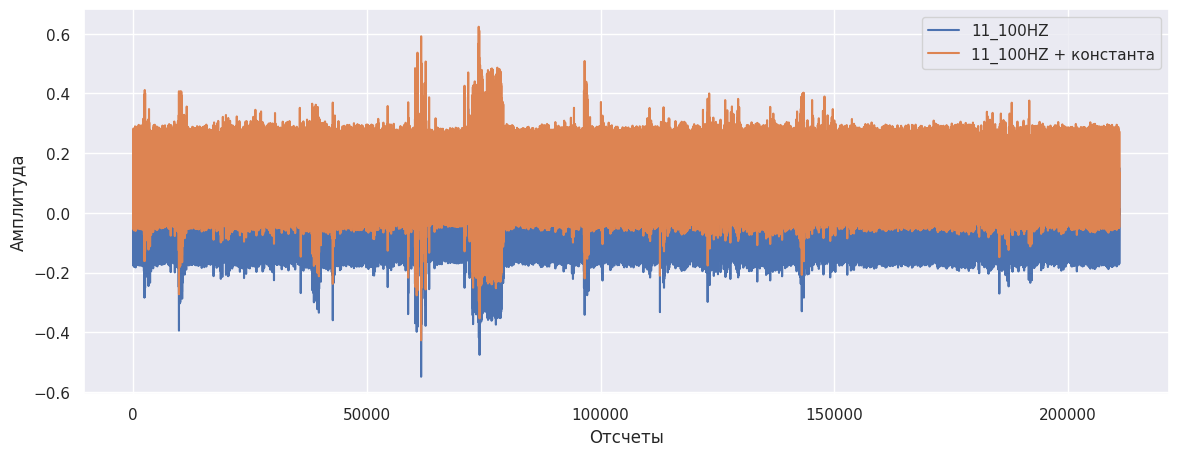

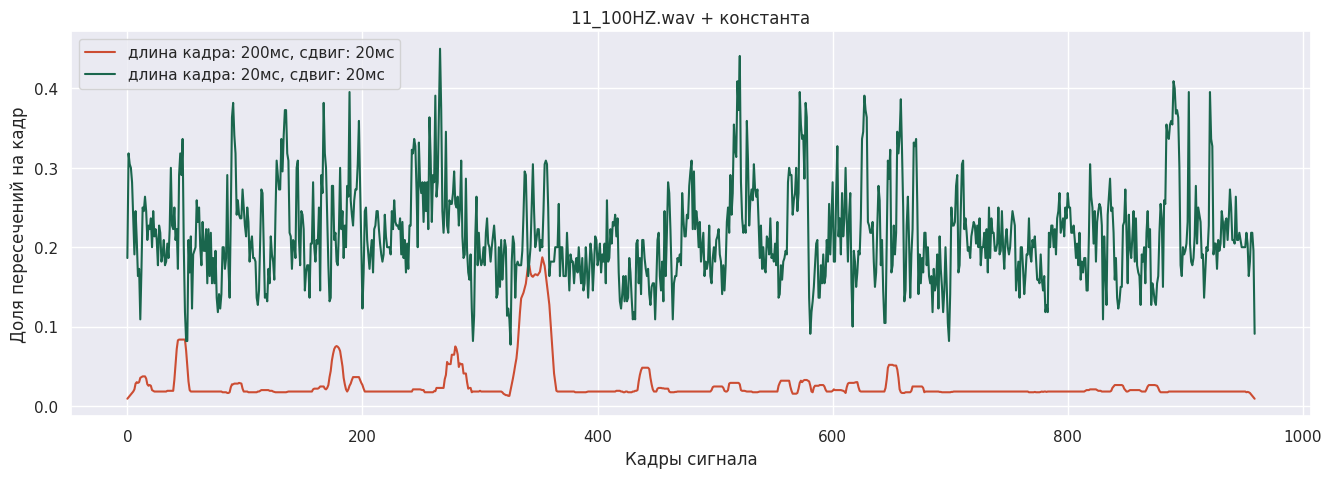

In [ ]:
# Добавляем к сигналу константу, строим осцилограммы
data_11_100HZ_const = data_11_100HZ + 0.122

plt.figure(figsize=(14, 5))
plt.plot(data_11_100HZ, label="11_100HZ")
plt.plot(data_11_100HZ_const, label="11_100HZ + константа")
plt.grid(True)
plt.xlabel("Отсчеты")
plt.ylabel("Амплитуда")
plt.legend()
plt.show()

# Строим графики ZCR
plt.figure(figsize=(16, 5))
z200_const = librosa.feature.zero_crossing_rate(
    data_11_100HZ_const, frame_length=t200, hop_length=t20
)
plt.title("11_100HZ.wav + константа")
plt.plot(z200_const[0], label="длина кадра: 200мс, сдвиг: 20мс", color=[0.8, 0.3, 0.2])

z20_const = librosa.feature.zero_crossing_rate(
    data_11_100HZ_const, frame_length=t20, hop_length=t20
)
plt.plot(z20[0], label="длина кадра: 20мс, сдвиг: 20мс", color=[0.1, 0.4, 0.3])
plt.ylabel("Доля пересечений на кадр")
plt.xlabel("Кадры сигнала")

plt.grid(True)
plt.legend()
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 4:</b>
<a id="answer-job4"></a>

* Как оценка ZCR связана с размером кадра?

При больше размере окна меньше доля пересечений на кадр

* Как изменится ZCR? Объясните результаты.

При добавление константы значение ZCR стало сильно менье.
Поскольку ZCR считает число раз, когда значение амплитуды поменяло знак, после добавления константы большая часть амлитуд стало положительными

</div>

<div class="alert alert-block alert-info">
<b>Задание 5. ZCR для обычного и зашумленного речевого сигнала</b> 
<a id="job5"></a>

* Постройте графики ZCR для чистого **SPCH_ME.wav** и зашумленного речевого сигнала **SMN1_22.wav**.
   
* В каких пределах изменяется ZCR?

* На каких участках речевого сигнала ZCR увеличивается?

* Добавьте к сигналу **SMN1_22.wav** константу ($122$). Как изменится ZCR?

* Объясните результаты.
</div>

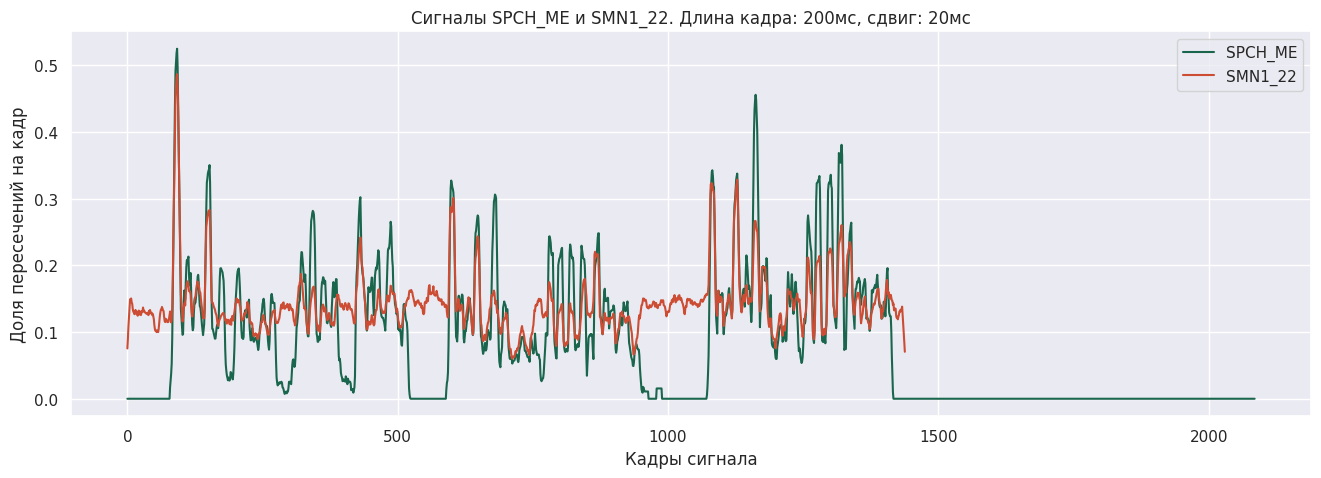

In [ ]:
# Загрузка сигнала (с частотой 8000)
data_SMN1_22, sr_SMN1_22 = librosa.load(Speech_dir + "//SMN1_22.wav", sr=sr8000)

# Строим графики ZCR
plt.figure(figsize=(16, 5))
plt.title("Сигналы SPCH_ME и SMN1_22. Длина кадра: 200мс, сдвиг: 20мс")
zdata_SPCH_ME = librosa.feature.zero_crossing_rate(
    data_SPCH_ME, frame_length=t200, hop_length=t20
)
plt.plot(zdata_SPCH_ME[0], label="SPCH_ME", color=[0.1, 0.4, 0.3])

zSMN1_22 = librosa.feature.zero_crossing_rate(
    data_SMN1_22, frame_length=t200, hop_length=t20
)
plt.plot(zSMN1_22[0], label="SMN1_22", color=[0.8, 0.3, 0.2])

plt.ylabel("Доля пересечений на кадр")
plt.xlabel("Кадры сигнала")

plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from IPython import display

display.display(display.Audio(data_SMN1_22, rate=sr8000))

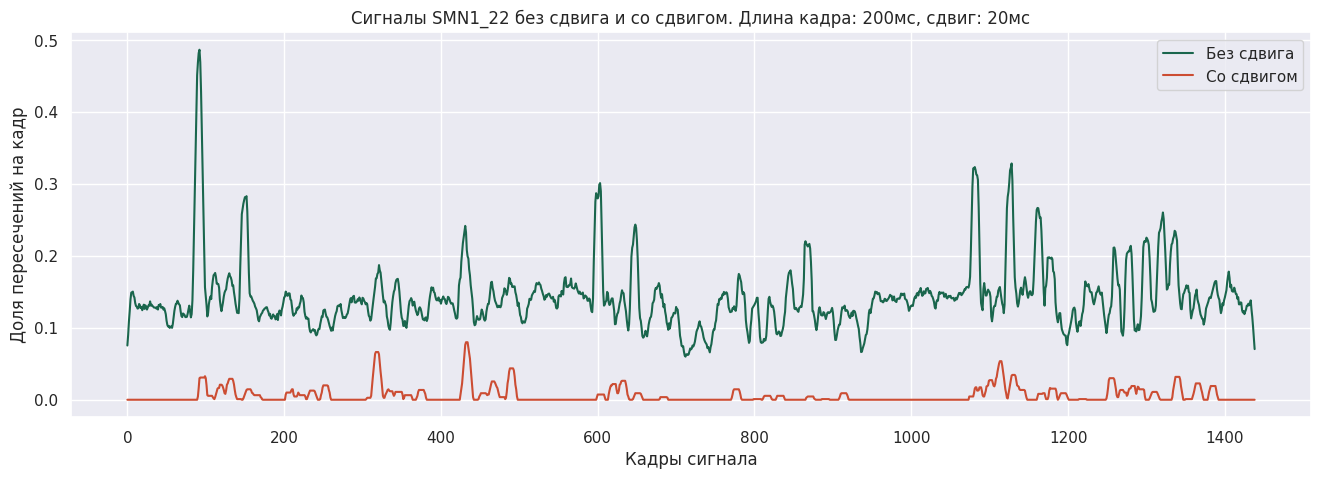

In [ ]:
# Добавляем к сигналу SMN1_22.wav константу и строим графики ZCR
data_SMN1_22_const = data_SMN1_22 + 0.122

plt.figure(figsize=(16, 5))
plt.title("Сигналы SMN1_22 без сдвига и со сдвигом. Длина кадра: 200мс, сдвиг: 20мс")
zSMN1_22 = librosa.feature.zero_crossing_rate(
    data_SMN1_22, frame_length=t200, hop_length=t20
)
plt.plot(zSMN1_22[0], label="Без сдвига", color=[0.1, 0.4, 0.3])

zSMN1_22_const = librosa.feature.zero_crossing_rate(
    data_SMN1_22_const, frame_length=t200, hop_length=t20
)
plt.plot(zSMN1_22_const[0], label="Со сдвигом", color=[0.8, 0.3, 0.2])

plt.ylabel("Доля пересечений на кадр")
plt.xlabel("Кадры сигнала")

plt.grid(True)
plt.legend()
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 5:</b>
<a id="answer-job5"></a>

* В каких пределах изменяется ZCR?

Для чистой речи 0-0.5, для зашумлённой 0.1-0.5

* На каких участках речевого сигнала ZCR увеличивается?

При прослушивание - на шипящих у чистого голоса.
Вместе с тем видно, что на 0 ZCR у чистой речи в зашумлённой все ещё есть коллебания из-за того, что даже во время речевых пауз происходят коллебания шума.

* Добавьте к сигналу **SMN1_22.wav** константу ($122$). Как изменится ZCR?

Также занулятся.

* Объясните результаты.

Ситуация как в прошлом пункте - прибавили константу, отрицательные амплитуды стали неотрицательными

</div>

<div class="alert alert-block alert-info">
<b>Задание 6. ZCR для гармонического сигнала различной частоты дискретизации</b> 
<a id="job6"></a>

* Сгенерируйте гармонику ($F_0 = 315$ Гц) с частотами дискретизации $11025, 20502, 44100$ Гц.

* Постройте графики ZCR.

* Объясните результаты.
</div>

In [ ]:
# Генерация тональных сигналов: основная частота, длительность(10 сек.), частота дискретизации (гц)
tone11 = librosa.tone(315, duration=10, sr=sr11025)
tone22 = librosa.tone(315, duration=10, sr=sr22050)
tone44 = librosa.tone(315, duration=10, sr=sr44100)

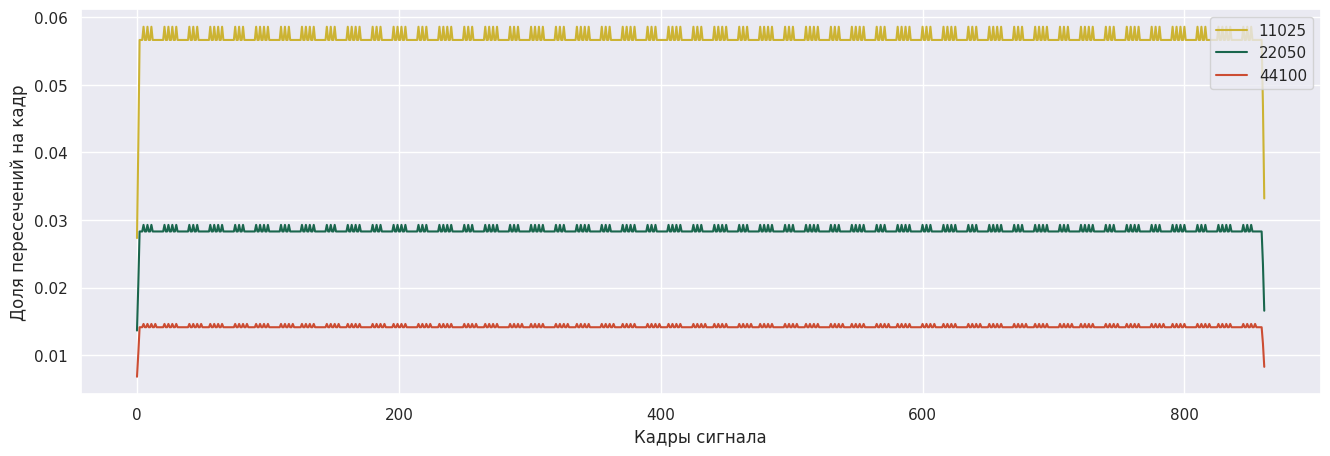

In [ ]:
# Вычисляем и визуализируем ZCR
plt.figure(figsize=(16, 5))
z_11025 = librosa.feature.zero_crossing_rate(tone11, frame_length=512, hop_length=128)
plt.plot(z_11025[0], label="11025", color=[0.8, 0.7, 0.2])

z_22050 = librosa.feature.zero_crossing_rate(tone22, frame_length=1024, hop_length=256)
plt.plot(z_22050[0], label="22050", color=[0.1, 0.4, 0.3])

z_44100 = librosa.feature.zero_crossing_rate(tone44, frame_length=2048, hop_length=512)
plt.plot(z_44100[0], label="44100", color=[0.8, 0.3, 0.2])

plt.ylabel("Доля пересечений на кадр")
plt.xlabel("Кадры сигнала")

plt.grid(True)
plt.legend()
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 6:</b>
<a id="answer-job6"></a>

* Объясните результаты.

ZCR обратно пропорционален частоте дискретизации, соответственно при увеличение частоты отсчётов $f_s$ на один период сигнала приходиться меньше изменений сигнала по знаку.
Само количество пересечений нуля остаётся тем же, однако на большем числе отсчётов оно условно сглаживается и распределяется на больше число наблюдений.
Так как условная синусоида не успевает пойти на убывание

</div>

<div class="alert alert-block alert-info">
<b>Задание 7. ZCR для различной частоты дискретизации</b> 
<a id="job7"></a>

* Постройте графики ZCR для сигналов **44sp_m.wav, 22sp_m.wav, 11sp_m.wav**.

* Меняется ли ZCR при изменении частоты дискретизации ($44$ кГц, $22$ кГц, $11$ кГц) сигнала?

* Объясните результаты.
</div>

In [ ]:
# Загрузка речевых сигналов (с частотами: 11025, 22050, 44100)
data_11025, sr_11025 = librosa.load(Speech_dir + "//11sp_m.wav", sr=sr11025)
data_22050, sr_22050 = librosa.load(Speech_dir + "//22sp_m.wav", sr=sr22050)
data_44100, sr_44100 = librosa.load(Speech_dir + "//44sp_m.wav", sr=sr44100)

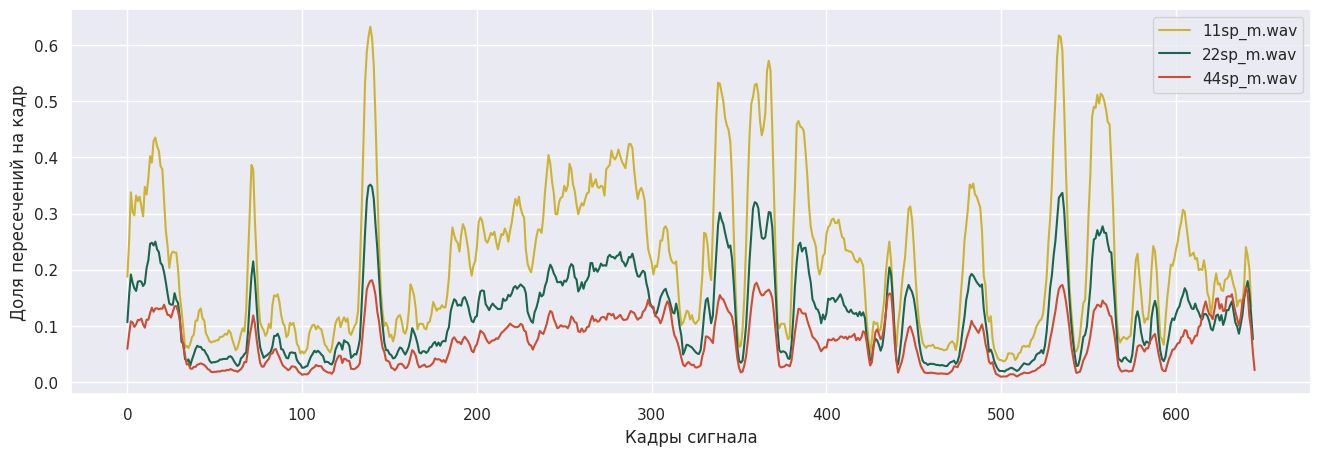

In [ ]:
# Вычисляем и визуализируем ZCR
z11025 = librosa.feature.zero_crossing_rate(
    data_11025, frame_length=512, hop_length=128
)
z22050 = librosa.feature.zero_crossing_rate(
    data_22050, frame_length=1024, hop_length=256
)
z44100 = librosa.feature.zero_crossing_rate(
    data_44100, frame_length=2048, hop_length=512
)

plt.figure(figsize=(16, 5))
plt.plot(z11025[0], label="11sp_m.wav", color=[0.8, 0.7, 0.2])
plt.plot(z22050[0], label="22sp_m.wav", color=[0.1, 0.4, 0.3])
plt.plot(z44100[0], label="44sp_m.wav", color=[0.8, 0.3, 0.2])
plt.ylabel("Доля пересечений на кадр")
plt.xlabel("Кадры сигнала")
plt.legend()
plt.grid(True)

<div class="alert alert-block alert-success">
<b>Ответ на задание 7:</b>
<a id="answer-job7"></a>

* Меняется ли ZCR при изменении частоты дискретизации ($44$ кГц, $22$ кГц, $11$ кГц) сигнала?

Да, меняется.

* Объясните результаты.

Как я писал в прошлом пункте, ZCR обратно пропорционален частоте дискретизации.
При том общая форма фигур на графике не изменяется, а становится сплющенная по оси `y`

</div>